<h1> Visualization: How did cities think about making patients' footprint information public? </h1>
<p> This project uses data from the World COVID-19 Pandemic and Citizen Life Survey, part of a research project that I participated in when I was a graduate research assistant at Seoul National University. The following codes exhibit how I process the data for visualization and visualize it. I have excluded some more detailed processes such as checking the values because I intended to make this presentation look concise. For people who are only interested in the result, please scroll down to the bottom and check the interpretation section. </p>

<h2> Data Pre-processing </h2>

In [1]:
import pandas as pd
import numpy as np
import pyreadstat
import math

import matplotlib.pyplot as plt

In [2]:
path = #... location of raw data
df, meta = pyreadstat.read_sav(path, usecols=['SQ1', 'qV_6', 'qII_3_4'])

In [3]:
cities = ['Seoul', 'Daegu', 'Tokyo', 'Osaka', 'Taipei', 'Hong Kong', 'Singapore',
         'New York', 'Los Angeles', 'Toronto', 'London', 'Berlin', 'Paris', 'Vienna',
         'Madrid', 'Rome', 'Lisbon', 'Cape Town', 'Stockholm', 'Oslo', 'Moscow', 'Sydeny',
         'Wellington', 'Manila', 'Sao Paulo', 'Buenos Aires', 'Santiago', 'Mexico City',
         'New Delhi', 'Jakarta']

df['city'] = df['SQ1'].apply(lambda x: cities[int(x)-1])

df['prog_cons'] = df['qV_6'].apply(lambda x: 'prog' if x < 6 else 'cons')

<h3> the following cell presents a snippet of the table after pre-processing </h3>

In [4]:
df.head()

,SQ1,qII_3_4,qV_6,city,prog_cons
0,1.0,7.0,7.0,Seoul,cons
1,1.0,4.0,8.0,Seoul,cons
2,1.0,1.0,5.0,Seoul,prog
3,1.0,3.0,6.0,Seoul,cons
4,1.0,2.0,6.0,Seoul,cons


<h3> code that retreves data in the structure suitable for visualization </h3>

In [5]:
cons_df = df.index[df['prog_cons']=='cons']
cons_df = df.iloc[cons_df]

prog_df = df.index[df['prog_cons']=='prog']
prog_df = df.iloc[prog_df]

In [6]:
cf = list()
cf_err = list() 

for c in cities:

    arr = cons_df.loc[cons_df['city']==c, 'qII_3_4'].values

    mean = arr.mean()
    std = arr.std()
    ci = 1.96*std/math.sqrt(len(arr))

    cf.append(mean)
    cf_err.append(ci)
    
pf = list()
pf_err = list() 

for c in cities:

    arr = prog_df.loc[prog_df['city']==c, 'qII_3_4'].values

    mean = arr.mean()
    std = arr.std()
    ci = 1.96*std/math.sqrt(len(arr))

    pf.append(mean)
    pf_err.append(ci)

<h2> Visualization </h2>

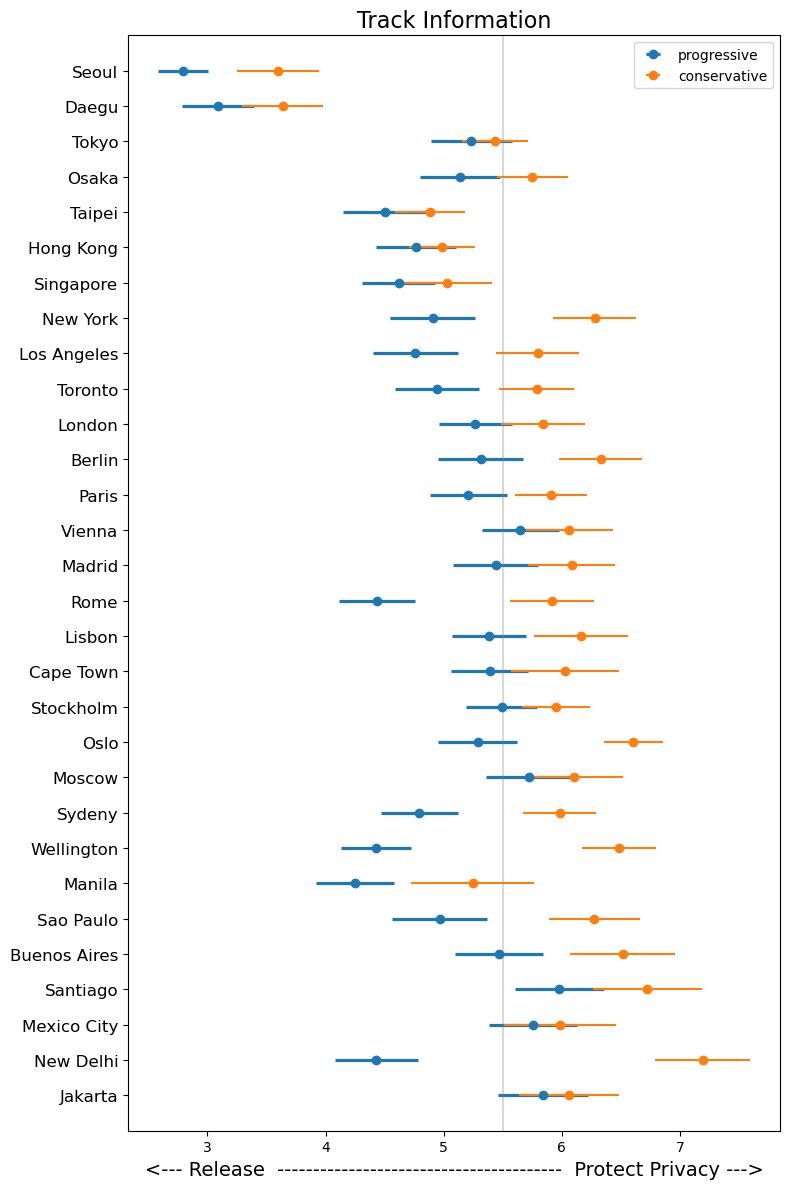

In [7]:
fig, ax = plt.subplots(figsize=(8,12))

dots1 = ax.errorbar(pf, cities, xerr=pf_err, fmt='o', color='tab:blue', label='progressive', elinewidth=2.3)
dots2 = ax.errorbar(cf, cities, xerr=cf_err, fmt='o', color='tab:orange', label='conservative')

midx, midy = [5.5, 5.5], [-5, 35]

mid_line = ax.plot(midx, midy, color='grey', alpha=0.3)

ax.tick_params(axis='y', labelsize=12)
ax.set_ylim([-1, 30])
ax.invert_yaxis()

plt.title('Track Information', fontsize=16)
plt.xlabel('<--- Release  '+ '-'*40 +'  Protect Privacy --->', fontsize=14)
plt.legend(loc=1)

fig.tight_layout()

#plt.savefig('portfo2.png', dpi=300)
plt.show()

<h2> Interpretation </h2>

<p> 1. The figure presents the different opinions about whether the government should disclose COVID patients' past travel history between samples who identified themselves as progressive and samples who identified themselves as conservative in each city. The smaller X value indicates one thinks the government should release the travel history, whereas the bigger X value indicates one thinks the personal travel history should be kept as private. The dot locates the mean, and the wings on the sides mean the 95% confidence interval.</p>
<p> 2. The result shows that it was universal that the conservatives tended to oppose the disclosure of patients' travel history, though the statistics were not always significant across cities. Seoul, New York, Berlin, and Rome were some of the cities that had a statistically significant difference. The greatest divergence between the conservative and the progressive was found in New Dehli, suggesting a local political tension concerning pandemic management.</p>
<p> 3. It was characteristic that Koreans, irrespective of their political ideology, tended to be in favor of the disclosure of patients' travel history on a global scale. This strong favorability can be seen from the support of stringency measures after the outbreak of the coronavirus.</p>